In [1]:
import sys 
sys.path.append("../src")
from data_loader import load_prices, load_returns

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

prices = load_prices()
log_returns = load_returns()

print(prices.shape)
print(log_returns.shape)

KeyboardInterrupt: 

In [ ]:
# run ADF test on  a price series
## study adfuller function structure from documentation x   

result = adfuller(prices["XOM"])
print("ADF Statistic:" , result[0])
print("p-value" , result[1])
print("Critical Values" , result[4])

ADF Statistic: -0.592303803919141
p-value 0.872711585968149
Critical Values {'1%': np.float64(-3.4346938104971554), '5%': np.float64(-2.863458518103151), '10%': np.float64(-2.567791394384679)}


In [ ]:
result = adfuller(log_returns["XOM"])
print("ADF Statistic: " , result[0])
print("p-value" , result[1])
print("Critical Values" , result[4])

ADF Statistic:  -13.558543588233311
p-value 2.3342119719387046e-25
Critical Values {'1%': np.float64(-3.4347170173134813), '5%': np.float64(-2.8634687603081486), '10%': np.float64(-2.5677968484444444)}


In [ ]:
def adf_test(series,name=""):
    result = adfuller(series)
    p_value = result[1]
    adf_stat = result[0]
    critical_5 = result[4]["5%"]
    stationary = p_value < 0.05

    print(f"{name}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.6f}")
    print(f"  Critical (5%) : {critical_5:.4f}")
    print(f"  Stationary    : {stationary}")
    print()
    
    return stationary

In [ ]:
adf_test(prices["XOM"] , "XOM_Price")
adf_test(prices["KO"], "KO Price")
adf_test(log_returns["XOM"], "XOM Log Returns")
adf_test(log_returns["KO"], "KO Log Returns")

XOM_Price
  ADF Statistic : -0.5923
  p-value       : 0.872712
  Critical (5%) : -2.8635
  Stationary    : False

KO Price
  ADF Statistic : -1.3926
  p-value       : 0.585825
  Critical (5%) : -2.8635
  Stationary    : False

XOM Log Returns
  ADF Statistic : -13.5585
  p-value       : 0.000000
  Critical (5%) : -2.8635
  Stationary    : True

KO Log Returns
  ADF Statistic : -11.8094
  p-value       : 0.000000
  Critical (5%) : -2.8635
  Stationary    : True



np.True_

In [ ]:
result = []
for ticker in prices.columns:
    price_stationary = adfuller(prices[ticker])[1] < 0.05
    return_stationary = adfuller(log_returns[ticker])[1] < 0.05
    result.append({
        "ticker" : ticker, 
        "price_stationary" : price_stationary,
        "return_stationary" : return_stationary
    })
    result_df = pd.DataFrame(result)
    print(result_df)
    print("\n Prices stationary:" , result_df["price_stationary"].sum())
    print("Returns stationary:" , result_df["return_stationary"].sum())
    print()
    print(result_df[result_df["price_stationary"] == True])


  ticker  price_stationary  return_stationary
0   AAPL             False               True

 Prices stationary: 0
Returns stationary: 1

Empty DataFrame
Columns: [ticker, price_stationary, return_stationary]
Index: []
  ticker  price_stationary  return_stationary
0   AAPL             False               True
1    ABT             False               True

 Prices stationary: 0
Returns stationary: 2

Empty DataFrame
Columns: [ticker, price_stationary, return_stationary]
Index: []
  ticker  price_stationary  return_stationary
0   AAPL             False               True
1    ABT             False               True
2   AMZN             False               True

 Prices stationary: 0
Returns stationary: 3

Empty DataFrame
Columns: [ticker, price_stationary, return_stationary]
Index: []
  ticker  price_stationary  return_stationary
0   AAPL             False               True
1    ABT             False               True
2   AMZN             False               True
3    AXP             

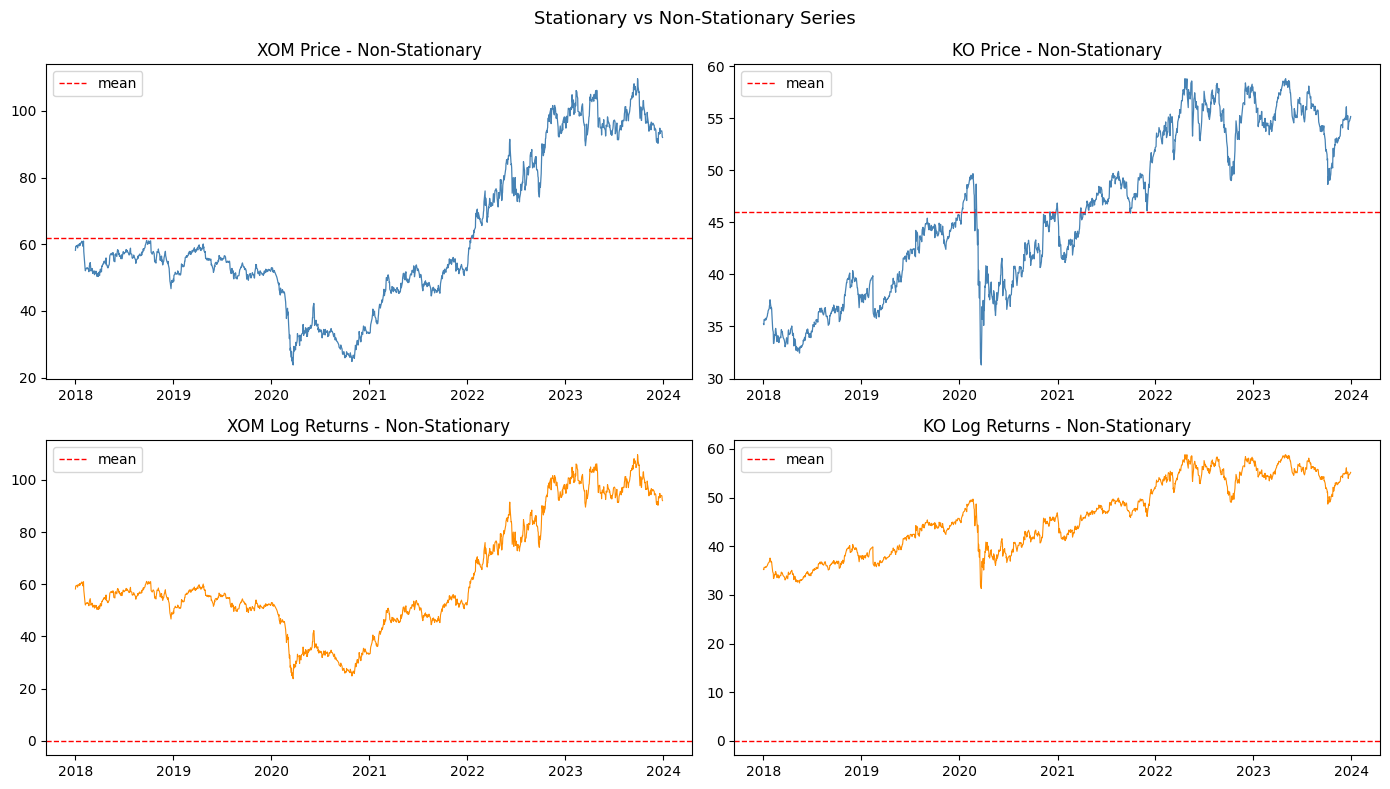

In [ ]:
# visualise stationary vs non - sstationary

fig, axes = plt.subplots(2,2,figsize = (14,8))

# non stationary 
axes[0][0].plot(prices.index , prices["XOM"] ,color = "steelblue" , linewidth = 0.9)
axes[0][0].set_title("XOM Price - Non-Stationary")
axes[0][0].axhline(prices["XOM"].mean() , color = "red" , linestyle = "--" , linewidth = 1 , label = "mean")
axes[0][0].legend()

axes[0][1].plot(prices.index , prices["KO"] ,color = "steelblue" , linewidth = 0.9)
axes[0][1].set_title("KO Price - Non-Stationary")
axes[0][1].axhline(prices["KO"].mean() , color = "red" , linestyle = "--" , linewidth = 1 , label = "mean")
axes[0][1].legend()

# stationary 
axes[1][0].plot(prices.index , prices["XOM"] ,color = "darkorange" , linewidth = 0.8)
axes[1][0].set_title("XOM Log Returns - Non-Stationary")
axes[1][0].axhline(0 , color = "red" , linestyle = "--" , linewidth = 1 , label = "mean")
axes[1][0].legend()

axes[1][1].plot(prices.index , prices["KO"] ,color = "darkorange" , linewidth = 0.8)
axes[1][1].set_title("KO Log Returns - Non-Stationary")
axes[1][1].axhline(0 , color = "red" , linestyle = "--" , linewidth = 1 , label = "mean")
axes[1][1].legend()

plt.suptitle("Stationary vs Non-Stationary Series" , fontsize = 13)
plt.tight_layout()
plt.savefig("../data/stationarity_plot.png" , dpi = 120)
plt.show()

In [ ]:
from data_loader import adf_test

adf_test(log_returns["V"] , "V Log Returns")

V Log Returns
  ADF Statistic : -10.6432
  p-value       : 0.000000
  Critical (5%) : -2.8635
  Stationary    : True



np.True_